# Linear Regression: California Housing Price Prediction

## Introduction
This notebook demonstrates a full supervised regression workflow using the California Housing dataset. The project focuses on understanding the dataset, building a baseline linear regression model, evaluating performance, and testing whether a smaller feature set improves the result.

## Project Goal
Predict median house value from demographic and housing-related variables, interpret model behavior, and build intuition for regression metrics and feature relevance.

## Machine Learning Concepts Used
- Supervised Learning
- Regression
- Exploratory Data Analysis
- Correlation Analysis
- Train/Test Split
- Linear Regression
- Residual Analysis
- Feature Selection

## Dataset
`sklearn.datasets.fetch_california_housing`

## Step 1: Import libraries

**What this section is doing**  
Import numerical, plotting, and machine-learning libraries used throughout the notebook. Keeping imports grouped makes the workflow easier to understand and debug.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Step 2: Load the dataset

**What this section is doing**  
Load the California Housing dataset and combine the features and target into one DataFrame so the entire problem can be inspected in a single place.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [2]:
housing = fetch_california_housing(as_frame=True)

X = housing.data.copy()
y = housing.target.copy()

df = X.copy()
df["target_med_house_value"] = y

print("Dataset shape:", df.shape)
print("Feature columns:", list(X.columns))
display(df.head())

Dataset shape: (20640, 9)
Feature columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target_med_house_value
0,8.3252,41.0000,6.9841,1.0238,322.0000,2.5556,37.8800,-122.2300,4.5260
1,8.3014,21.0000,6.2381,0.9719,"2,401.0000",2.1098,37.8600,-122.2200,3.5850
2,7.2574,52.0000,8.2881,1.0734,496.0000,2.8023,37.8500,-122.2400,3.5210
3,5.6431,52.0000,5.8174,1.0731,558.0000,2.5479,37.8500,-122.2500,3.4130
4,3.8462,52.0000,6.2819,1.0811,565.0000,2.1815,37.8500,-122.2500,3.4220


## Step 3: Inspect structure and data quality

**What this section is doing**  
Check the dataset's shape, data types, missing values, and summary statistics before modeling. This prevents training on misunderstood inputs.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [3]:
print(df.info())

print("\nMissing values by column:")
display(df.isna().sum())

print("\nSummary statistics:")
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   MedInc                  20640 non-null  float64
 1   HouseAge                20640 non-null  float64
 2   AveRooms                20640 non-null  float64
 3   AveBedrms               20640 non-null  float64
 4   Population              20640 non-null  float64
 5   AveOccup                20640 non-null  float64
 6   Latitude                20640 non-null  float64
 7   Longitude               20640 non-null  float64
 8   target_med_house_value  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Missing values by column:


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
target_med_house_value,0



Summary statistics:


,count,mean,std,min,25%,50%,75%,max
MedInc,"20,640.0000",3.8707,1.8998,0.4999,2.5634,3.5348,4.7432,15.0001
HouseAge,"20,640.0000",28.6395,12.5856,1.0000,18.0000,29.0000,37.0000,52.0000
AveRooms,"20,640.0000",5.4290,2.4742,0.8462,4.4407,5.2291,6.0524,141.9091
AveBedrms,"20,640.0000",1.0967,0.4739,0.3333,1.0061,1.0488,1.0995,34.0667
Population,"20,640.0000","1,425.4767","1,132.4621",3.0000,787.0000,"1,166.0000","1,725.0000","35,682.0000"
AveOccup,"20,640.0000",3.0707,10.3860,0.6923,2.4297,2.8181,3.2823,"1,243.3333"
Latitude,"20,640.0000",35.6319,2.1360,32.5400,33.9300,34.2600,37.7100,41.9500
Longitude,"20,640.0000",-119.5697,2.0035,-124.3500,-121.8000,-118.4900,-118.0100,-114.3100
target_med_house_value,"20,640.0000",2.0686,1.1540,0.1500,1.1960,1.7970,2.6472,5.0000


## Step 4: Visualize distributions and feature-target relationships

**What this section is doing**  
Use histograms and scatter plots to build intuition about variable distributions and potential linear relationships with the target.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

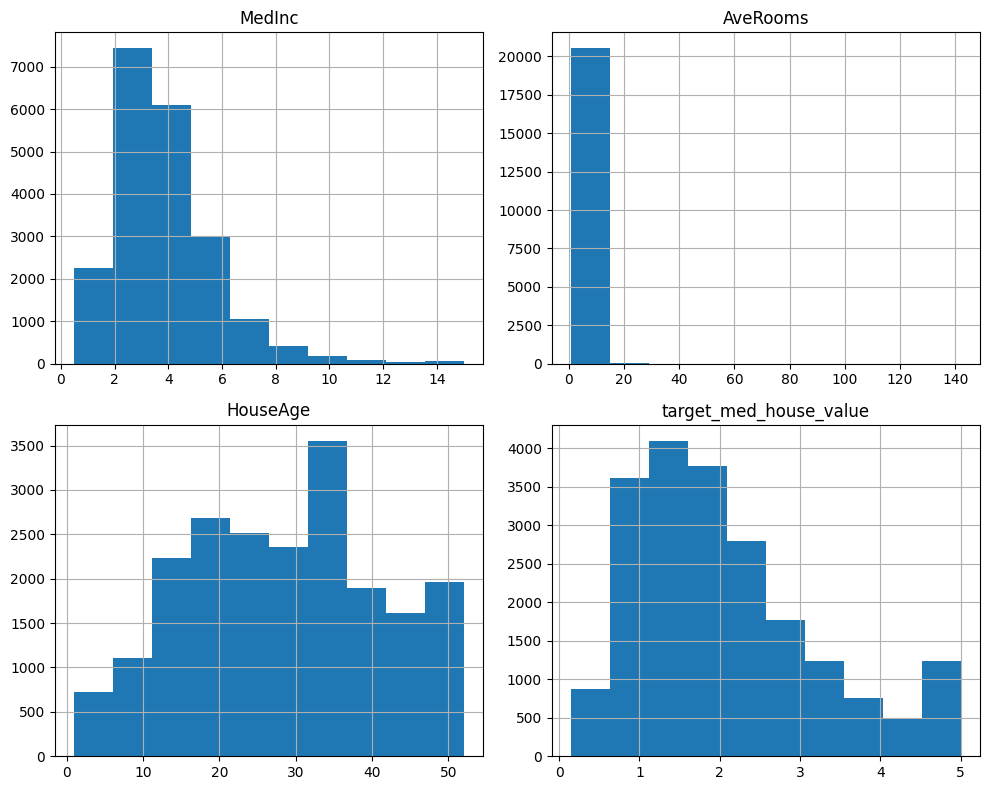

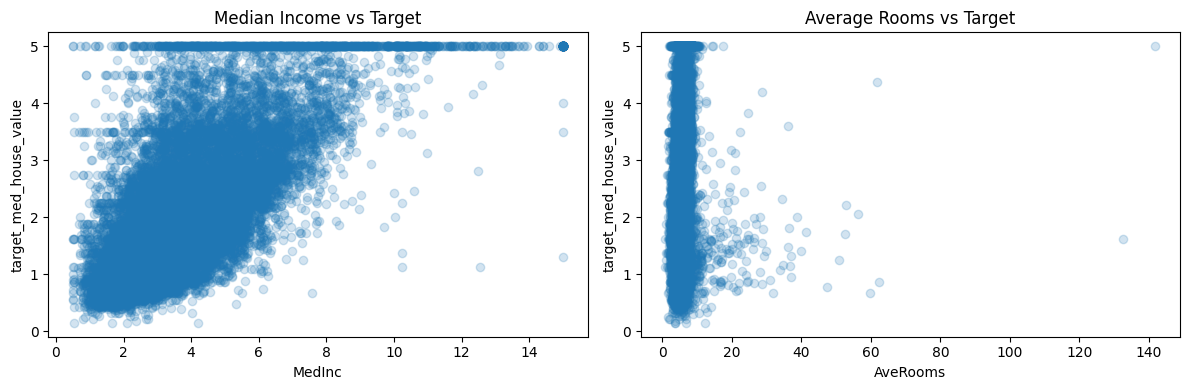

In [4]:
df[["MedInc", "AveRooms", "HouseAge", "target_med_house_value"]].hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["MedInc"], df["target_med_house_value"], alpha=0.2)
axes[0].set_title("Median Income vs Target")
axes[0].set_xlabel("MedInc")
axes[0].set_ylabel("target_med_house_value")

axes[1].scatter(df["AveRooms"], df["target_med_house_value"], alpha=0.2)
axes[1].set_title("Average Rooms vs Target")
axes[1].set_xlabel("AveRooms")
axes[1].set_ylabel("target_med_house_value")

plt.tight_layout()
plt.show()

## Step 5: Measure feature relevance with correlation

**What this section is doing**  
For a linear baseline, correlation is a useful first-pass signal for which numeric variables appear more strongly related to the target.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [5]:
corr_with_target = (
    df.corr(numeric_only=True)["target_med_house_value"]
      .sort_values(ascending=False)
)

display(corr_with_target.to_frame("correlation_with_target"))

,correlation_with_target
target_med_house_value,1.0000
MedInc,0.6881
AveRooms,0.1519
HouseAge,0.1056
AveOccup,-0.0237
Population,-0.0246
Longitude,-0.0460
AveBedrms,-0.0467
Latitude,-0.1442


## Step 6: Create training and testing sets

**What this section is doing**  
Split the data into train and test sets so the model can be evaluated on unseen examples.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (16512, 8)
X_test shape : (4128, 8)


## Step 7: Train the baseline regression model

**What this section is doing**  
Fit a baseline linear regression model before trying anything more complex. A strong baseline is essential for meaningful comparison.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Training complete.")

Intercept: -37.02327770606409
Training complete.


## Step 8: Generate predictions and inspect examples

**What this section is doing**  
Create predictions on the test set and inspect a sample of actual vs predicted values to make the errors concrete.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [8]:
y_pred = model.predict(X_test)

preview = pd.DataFrame({
    "actual": y_test.values[:15],
    "predicted": y_pred[:15],
    "error": y_test.values[:15] - y_pred[:15]
})

display(preview)

,actual,predicted,error
0,0.4770,0.7191,-0.2421
1,0.4580,1.7640,-1.3060
2,5.0000,2.7097,2.2904
3,2.1860,2.8389,-0.6529
4,2.7800,2.6047,0.1753
5,1.5870,2.0118,-0.4248
6,1.9820,2.6455,-0.6635
7,1.5750,2.1688,-0.5938
8,3.4000,2.7407,0.6593
9,4.4660,3.9156,0.5504


## Step 9: Evaluate with regression metrics

**What this section is doing**  
Use MAE, RMSE, and R² together because each metric highlights a different aspect of model quality.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [9]:
metrics_df = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R^2"],
    "value": [
        mean_absolute_error(y_test, y_pred),
        mean_squared_error(y_test, y_pred) ** 0.5,
        r2_score(y_test, y_pred)
    ]
})

display(metrics_df)

,metric,value
0,MAE,0.5332
1,RMSE,0.7456
2,R^2,0.5758


## Step 10: Analyze residuals

**What this section is doing**  
Residual analysis helps reveal whether the model systematically misses certain ranges of the target or shows evidence of non-linearity.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

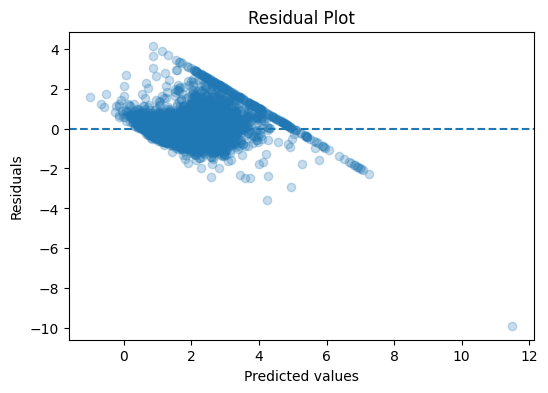

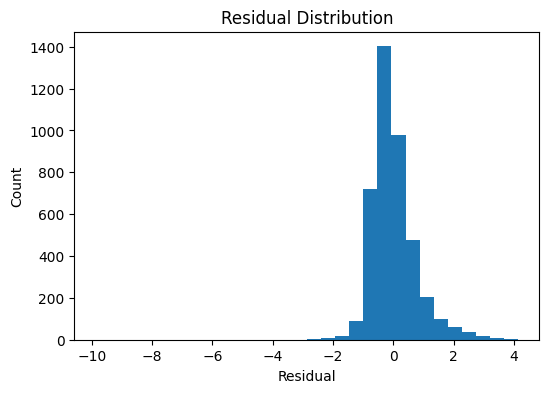

In [10]:
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.25)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.show()

## Step 11: Interpret model coefficients

**What this section is doing**  
For linear regression, coefficients provide a direct way to inspect the direction and magnitude of each feature's influence. Scale still matters, so coefficient size should be interpreted carefully.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [11]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_,
    "abs_coefficient": np.abs(model.coef_)
}).sort_values("abs_coefficient", ascending=False)

display(coef_df)

,feature,coefficient,abs_coefficient
3,AveBedrms,0.7831,0.7831
0,MedInc,0.4487,0.4487
7,Longitude,-0.4337,0.4337
6,Latitude,-0.4198,0.4198
2,AveRooms,-0.1233,0.1233
1,HouseAge,0.0097,0.0097
5,AveOccup,-0.0035,0.0035
4,Population,-0.0000,0.0000


## Step 12: Refine the model with a selected feature subset

**What this section is doing**  
Retrain the model using only the most strongly correlated features and compare performance. This tests whether a smaller input space helps or hurts the baseline.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [12]:
selected_features = (
    corr_with_target.drop("target_med_house_value")
    .abs()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

print("Selected features:", selected_features)

X_small = X[selected_features]

X_small_train, X_small_test, y_small_train, y_small_test = train_test_split(
    X_small, y, test_size=0.2, random_state=42
)

model_small = LinearRegression()
model_small.fit(X_small_train, y_small_train)
y_small_pred = model_small.predict(X_small_test)

refined_metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R^2"],
    "baseline_model": [
        mean_absolute_error(y_test, y_pred),
        mean_squared_error(y_test, y_pred) ** 0.5,
        r2_score(y_test, y_pred)
    ],
    "selected_feature_model": [
        mean_absolute_error(y_small_test, y_small_pred),
        mean_squared_error(y_small_test, y_small_pred) ** 0.5,
        r2_score(y_small_test, y_small_pred)
    ]
})

display(refined_metrics)

Selected features: ['MedInc', 'AveRooms', 'Latitude', 'HouseAge', 'AveBedrms']


,metric,baseline_model,selected_feature_model
0,MAE,0.5332,0.5797
1,RMSE,0.7456,0.7989
2,R^2,0.5758,0.5129


## Step 13: Final analysis and next steps

**What this section is doing**  
Close the notebook with a written interpretation of the results, the main takeaways, limitations, and logical next experiments.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

### Analysis of Results

**1. Data Understanding & Feature Relevance (Steps 3, 4, 5):**
- The dataset contains 20,640 entries with 8 features and no missing values, indicating a clean dataset for immediate use.
- Histograms showed varied distributions for features like `MedInc` (right-skewed) and `HouseAge` (bimodal), while scatter plots hinted at a positive linear relationship between `MedInc` and `target_med_house_value`.
- Correlation analysis (Step 5) confirmed `MedInc` (0.6881) as the most strongly correlated feature with the median house value, followed by `AveRooms` (0.1519). `Latitude` (-0.1442) also showed a notable, albeit negative, correlation.

**2. Baseline Model Performance (Steps 7, 8, 9):**
- The initial Linear Regression model, trained on all features, yielded the following metrics:
    - **MAE (Mean Absolute Error):** 0.5332 (average absolute difference between predicted and actual values)
    - **RMSE (Root Mean Squared Error):** 0.7456 (penalizes larger errors more)
    - **R² Score:** 0.5758 (approximately 57.58% of the variance in the target is explained by the model)
- These metrics indicate a decent baseline performance, but there's room for improvement.

**3. Residual Analysis (Step 10):**
- The residual plot showed a heteroscedastic pattern (residuals spread out as predicted values increase), suggesting that the model might struggle with higher house values. There's also a visible upward curve, indicating potential non-linearity that the linear model isn't capturing.
- The residual distribution was roughly normal but with some skewness, reinforcing the observations from the scatter plot and the heteroscedasticity.

**4. Model Coefficients (Step 11):**
- Coefficients provided insight into feature importance in the baseline model. `AveBedrms` had the largest absolute coefficient (0.7831), followed by `MedInc` (0.4487). While `AveBedrms` had a high coefficient, its correlation with the target was low, suggesting potential multicollinearity or complex interactions with other features.

**5. Refined Model with Selected Features (Step 12):**
- Retraining the model with only the top 5 correlated features (`MedInc`, `AveRooms`, `Latitude`, `HouseAge`, `AveBedrms`) resulted in a slight **decrease in performance**:
    - **MAE:** 0.5797 (worse than baseline)
    - **RMSE:** 0.7989 (worse than baseline)
    - **R² Score:** 0.5129 (worse than baseline)
- This indicates that removing features, even those with lower individual correlation, might have removed valuable information that contributed to the overall model fit. The full set of features, despite some having lower individual correlation, collectively provided a better prediction.

### Main Takeaways:
- The California Housing dataset provides a good starting point for regression tasks.
- Simple Linear Regression offers a reasonable baseline, but its performance is limited by the inherent linearity assumption, especially given the observed residual patterns.
- Feature selection based solely on individual correlation with the target may not always improve model performance, as features can have complex interactions or contribute subtly to the model's predictive power.

### Potential Next Steps:

1.  **Feature Engineering:** Create new features from existing ones (e.g., `rooms_per_person`, `bedrooms_per_room`) to capture more complex relationships.
2.  **Polynomial Features:** Introduce polynomial features to allow the linear model to capture non-linear relationships observed in the residual plot.
3.  **Regularization:** Implement Ridge or Lasso regression to handle potential multicollinearity among features and prevent overfitting.
4.  **Explore Non-Linear Models:** Experiment with more sophisticated non-linear regression models such as Decision Trees, Random Forests, Gradient Boosting Machines (e.g., XGBoost, LightGBM), or Support Vector Regressors, which can better capture complex relationships and non-linearities.
5.  **Hyperparameter Tuning:** For more complex models, perform hyperparameter tuning using techniques like GridSearchCV or RandomizedSearchCV to find optimal model configurations.
6.  **Geospatial Features:** Given `Latitude` and `Longitude` features, consider clustering or creating region-based features to account for geographical influences on housing prices.
7.  **Outlier Detection/Handling:** Investigate outliers in the data (e.g., using Isolation Forest or Z-score) and determine if they should be removed or transformed.